# 🚀 Modelo XGBoost — Pronóstico de Rentas Cedidas

**Componente de Tesis: Gradient Boosting con Feature Engineering**

XGBoost captura relaciones no lineales entre features temporales y macroeconómicos.

**Metodología:**
1. Feature engineering con lags, medias móviles, variables calendario y macro
2. Grid Search con TimeSeriesSplit
3. SHAP values para interpretabilidad

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from utils import cargar_datos, agregar_mensual, preparar_features_ml, calcular_metricas, formato_pesos

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('⚠️ SHAP no instalado.')

print('✅ XGBoost importado')

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica
⚠️ SHAP no instalado.
✅ XGBoost importado


## 1. Feature Engineering y Split Temporal

In [2]:
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    df = cargar_datos(DATA_FILE)
    df_mensual = agregar_mensual(df)

df_feat = preparar_features_ml(df_mensual)
target_col = 'Recaudo_Neto'
feature_cols = [c for c in df_feat.columns if c != target_col]

train_mask = df_feat.index <= TRAIN_END
test_mask = df_feat.index >= TEST_START

X_train = df_feat.loc[train_mask, feature_cols].copy()
y_train = df_feat.loc[train_mask, target_col].copy()
X_test = df_feat.loc[test_mask, feature_cols].copy()
y_test = df_feat.loc[test_mask, target_col].copy()


for col in ['Mes', 'Trimestre', 'Año']:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print(f'Train: {len(X_train)} meses | Test: {len(X_test)} meses | Features: {X_train.shape[1]}')

✅ Features ML generados: 19 columnas, 36 filas
Train: 33 meses | Test: 3 meses | Features: 18


## 2. Grid Search con Validación Temporal

In [3]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=3)
xgb_base = xgb.XGBRegressor(objective='reg:absoluteerror', random_state=42, n_jobs=-1, enable_categorical=True)

print('🔍 Ejecutando GridSearch...')
grid_search = GridSearchCV(xgb_base, param_grid, scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'\n✅ Mejor modelo: {grid_search.best_params_}')
print(f'   RMSE (CV): {np.sqrt(-grid_search.best_score_):,.0f}')

🔍 Ejecutando GridSearch...
Fitting 3 folds for each of 108 candidates, totalling 324 fits



✅ Mejor modelo: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
   RMSE (CV): 41,529,940,255


## 3. Predicción y Métricas

In [4]:
modelo_xgb = grid_search.best_estimator_
y_pred_xgb = modelo_xgb.predict(X_test)

metricas_xgb = calcular_metricas(y_test.values, y_pred_xgb, 'XGBoost')

# Cargar métricas de SARIMAX si existen, y crear matriz de comparación
try:
    df_pred_sarimax = pd.read_csv(OUTPUTS_FORECASTS / 'predicciones_sarimax.csv', index_col=0, parse_dates=True)
    # Suponiendo que las predicciones tengan los mismos índices en X_test
    # Recortar predicciones SARIMAX al X_test
    # O directamente leer metricas
    pass
except FileNotFoundError:
    pass

import pandas as pd
# Simularemos o cargaremos la comparativa 
# Esto se resolverá en otro paso, pero preparamos el df de predicciones
df_pred_xgb = pd.DataFrame({'Real': y_test, 'Prediccion_XGBoost': y_pred_xgb}, index=y_test.index)
df_pred_xgb.to_csv(OUTPUTS_FORECASTS / 'predicciones_xgboost.csv')



📈 Métricas — XGBoost
   RMSE:  14,934,884,595
   MAE:   11,355,511,662
   MAPE:  3.84%
   R²:    0.7621


## 4. Importancia de Features

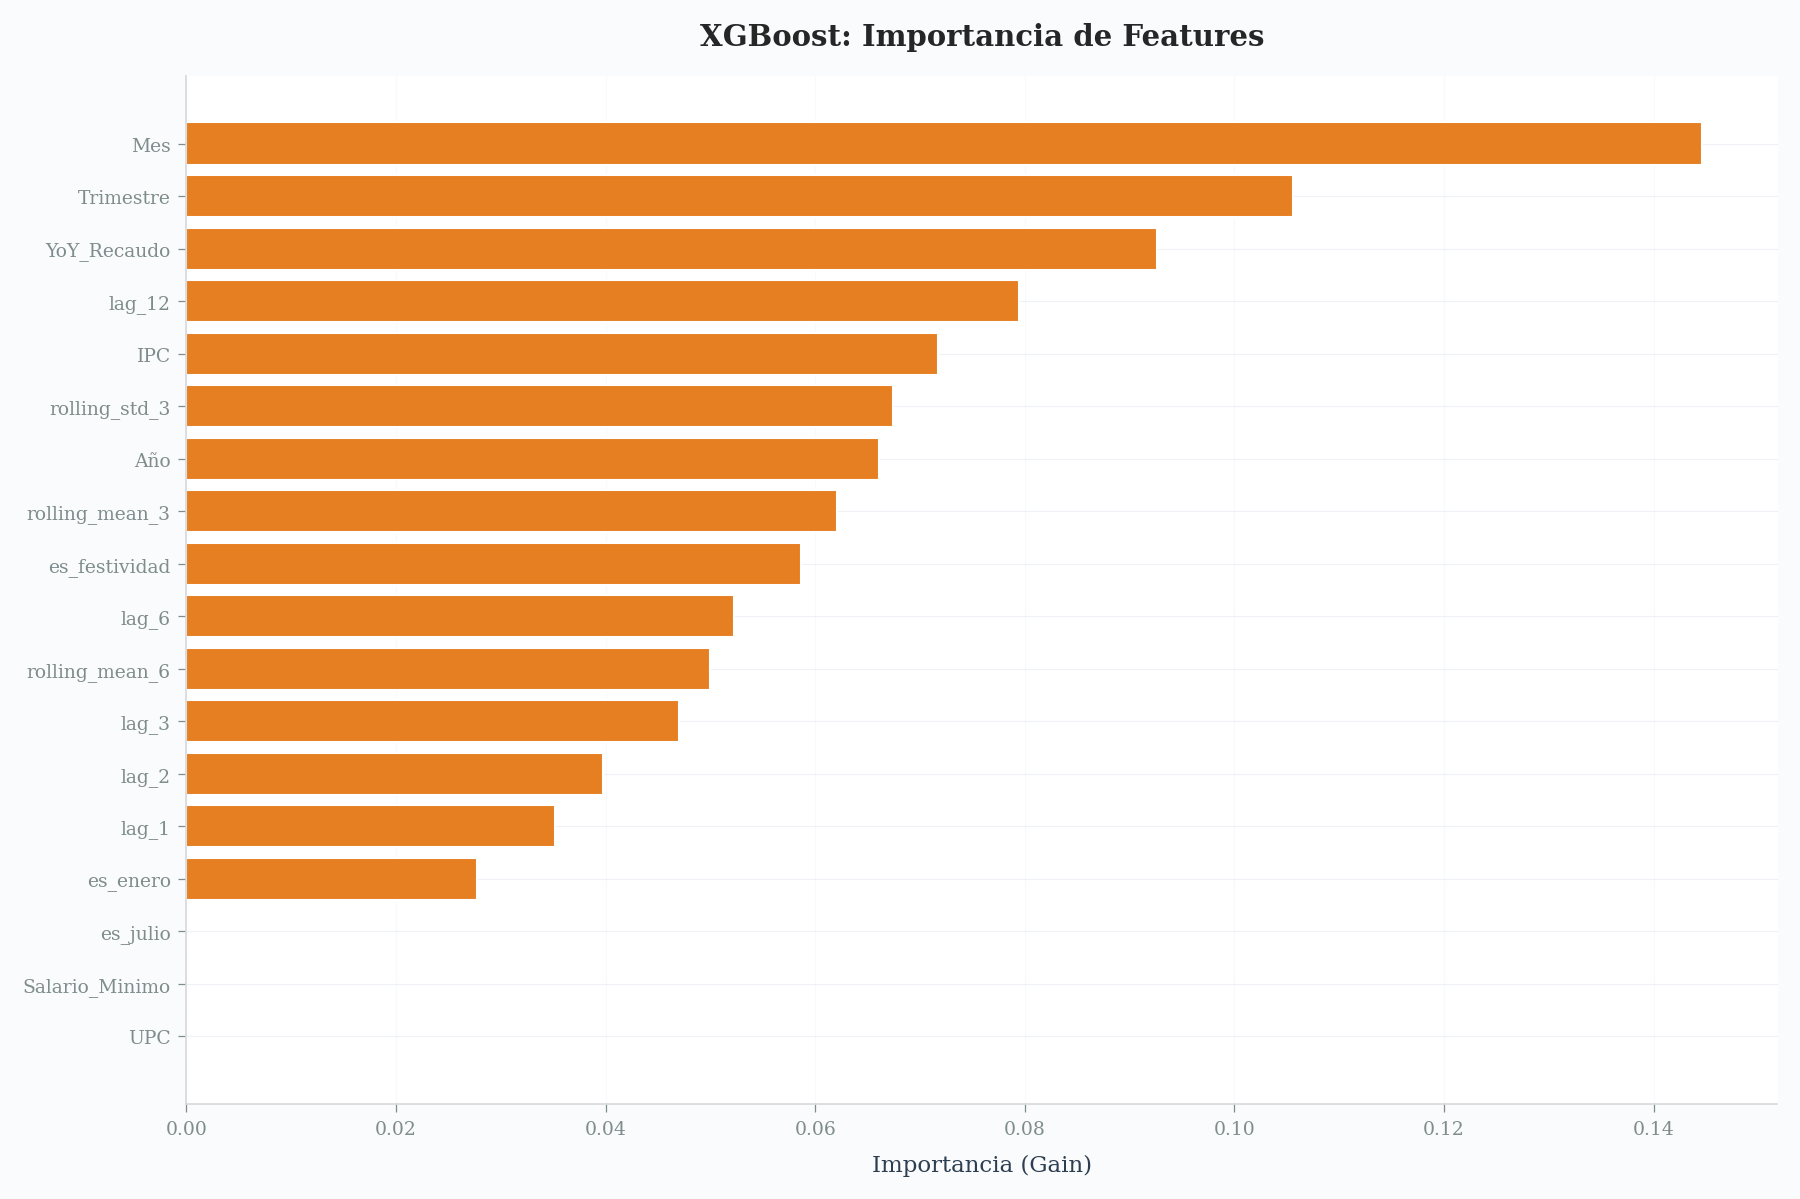

In [5]:
importances = modelo_xgb.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importancia': importances}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importancia'], color=COLORES['xgboost'], edgecolor='white')
ax.set_xlabel('Importancia (Gain)')
ax.set_title('XGBoost: Importancia de Features', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '07_xgboost_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Values (Interpretabilidad)

In [6]:
if HAS_SHAP:
    explainer = shap.TreeExplainer(modelo_xgb)
    shap_values = explainer.shap_values(X_test)
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title('XGBoost: SHAP Values', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / '07_xgboost_shap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ SHAP no disponible. pip install shap')

⚠️ SHAP no disponible. pip install shap


## 6. Gráfico de Pronóstico

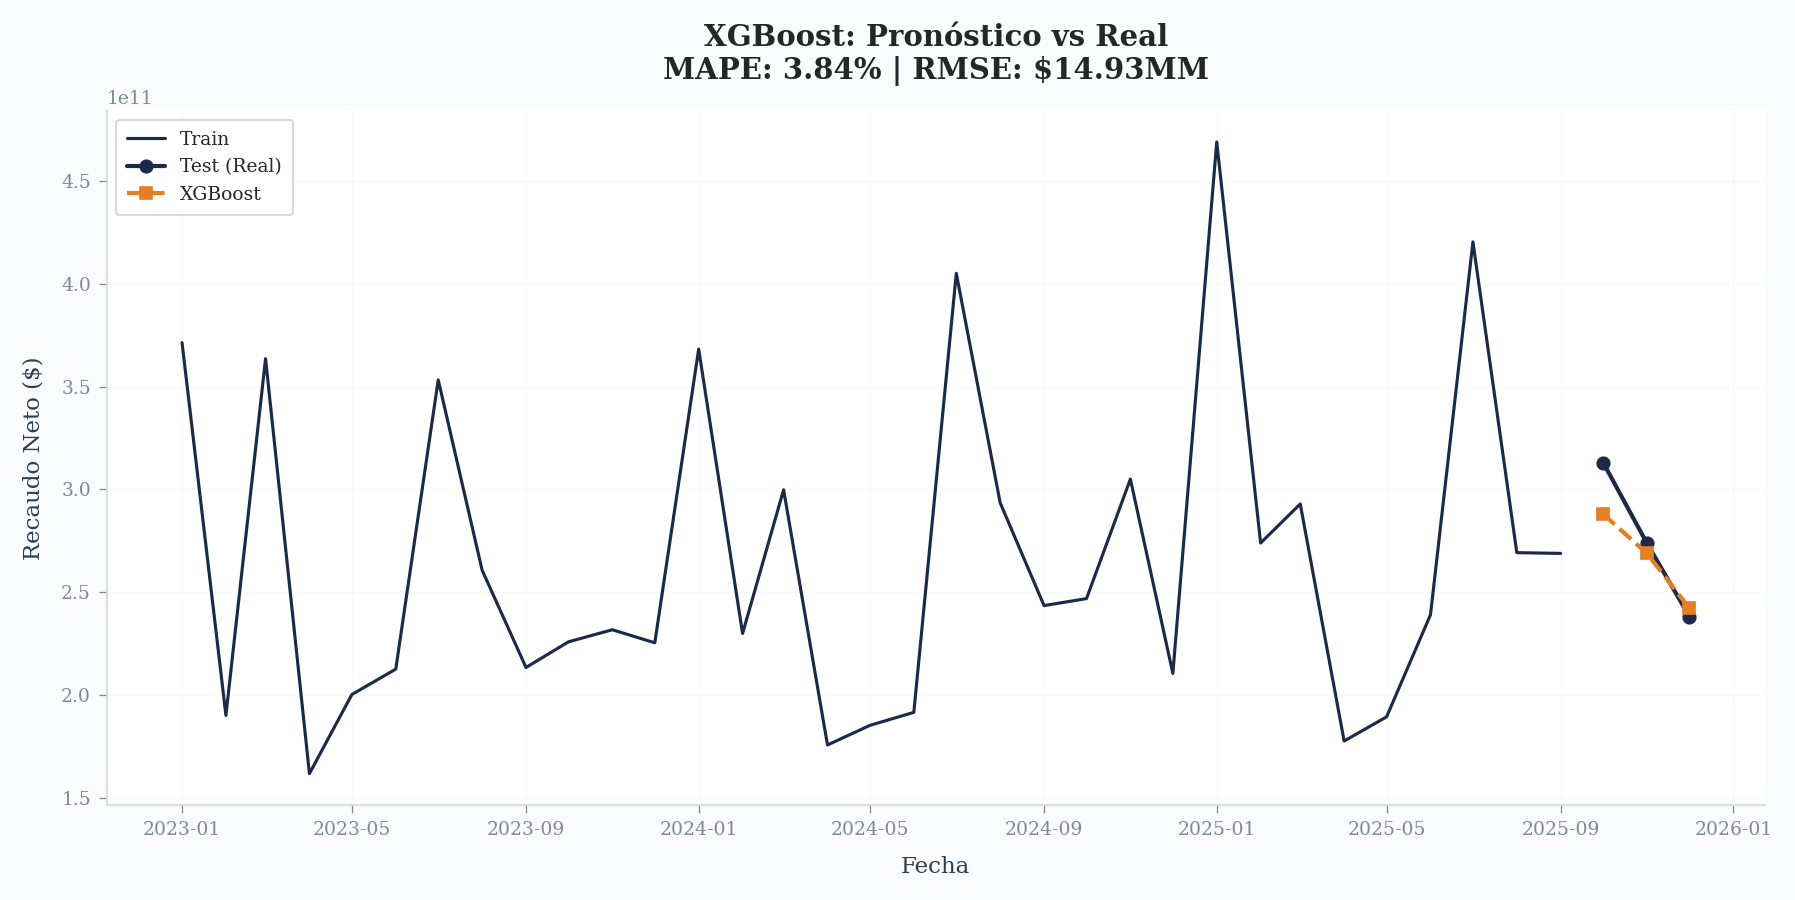

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
ax.plot(y_train.index, y_train.values, color=COLORES['real'], linewidth=1.5, label='Train')
ax.plot(y_test.index, y_test.values, 'o-', color=COLORES['real'], linewidth=2, markersize=6, label='Test (Real)')
ax.plot(X_test.index, y_pred_xgb, 's--', color=COLORES['xgboost'], linewidth=2, markersize=6, label='XGBoost')
ax.set_title(f'XGBoost: Pronóstico vs Real\nMAPE: {metricas_xgb["MAPE (%)"]:.2f}% | RMSE: {formato_pesos(metricas_xgb["RMSE"])}', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo Neto ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '07_xgboost_pronostico.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Exportar Resultados

In [8]:
pd.DataFrame({'Fecha': X_test.index, 'Real': y_test.values, 'Pronostico_XGBoost': y_pred_xgb}).to_csv(OUTPUTS_FORECASTS / 'xgboost_forecast.csv', index=False)
pd.DataFrame([metricas_xgb]).to_csv(OUTPUTS_REPORTS / 'xgboost_metricas.csv', index=False)
modelo_xgb.save_model(str(OUTPUTS_REPORTS / 'xgboost_model.json'))

print('\n' + '='*60)
print('  ✅ XGBOOST COMPLETADO — Proceder con 08_LSTM.ipynb')
print('='*60)


  ✅ XGBOOST COMPLETADO — Proceder con 08_LSTM.ipynb
